# Transformer — Wheat Price Direction Forecasting

This notebook trains a Transformer (encoder-only) model to predict the **next-day direction**
(up / down) of wheat futures prices, following the VIP Notebook Resubmission Guidelines.

**Pipeline overview:**
1. Preprocessing — load 31 FRED-MD macro features, apply t-code transformations, align to daily frequency with a 1-month reporting delay, and create 30-day lagged price features
2. Data Splitting — chronological train / validation / test split; scaler fit on training data only
3. Model — Transformer encoder with sliding-window sequences over daily feature vectors
4. Evaluation — accuracy, precision, recall, F1, confusion matrix, ROC-AUC

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import pickle
import warnings
warnings.filterwarnings('ignore')

from abc import ABC, abstractmethod
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_auc_score, classification_report
)
import matplotlib.pyplot as plt
import seaborn as sns

print('Imports loaded!')

Imports loaded!


In [2]:
"""
Base Template for Forecasting Models
"""

class BaseForecastModel(ABC):

    def __init__(self, task_type: str, **hyperparameters):
        self.task_type = task_type
        self.hyperparameters = hyperparameters

    @abstractmethod
    def fit(self, X_train, y_train):
        """Train your model on the training data."""
        pass

    @abstractmethod
    def predict(self, X):
        """Make predictions on new data."""
        pass

    @abstractmethod
    def evaluate(self, X_test, y_test):
        """Evaluate model performance on test data."""
        pass

    @abstractmethod
    def save(self, filepath: str):
        """Save your trained model to a file."""
        pass

    @abstractmethod
    def load(self, filepath: str):
        """Load a previously saved model."""
        pass


print('Base class defined!')

Base class defined!


## 1. Preprocessing

### 1.1 Feature Selection
We use exactly the 31 FRED-MD variables specified in the guidelines. No features are added or removed.

### 1.2 Macro Data (FRED-MD)
Three vintages are loaded to avoid look-ahead bias in the macro data:
- **Train vintage** (`2014-12.csv`): covers Aug 1999 – Nov 2014
- **Validation vintage** (`FRED-MD_2024m12.csv`): covers Dec 2014 – Nov 2024
- **Test vintage** (`2026-01-MD.csv`): covers Dec 2024 – Dec 2025

A **1-month reporting delay** is applied: each day in month M is assigned month M−1's macro values, since FRED-MD is released with a one-month lag. Monthly macro data is then **forward-filled** onto daily trading dates.

Each variable is transformed for stationarity using the t-codes embedded in the CSV (see §1.2 of guidelines).

### 1.3 Price Features and Target Variable
- **Input**: 30 lagged daily closing prices (`lag_1` … `lag_30`), i.e., prices at t−1 through t−30
- **Target**: binary direction — `1` if close[t] > close[t−1], else `0`
- All features are shifted so prediction at time t uses only data from t−1 and earlier (no look-ahead)

In [3]:
# ── 31 required FRED-MD features (Guidelines §1.1) ───────────────────────────
FRED_FEATURES = [
    'RPI', 'W875RX1', 'CMRMTSPLx', 'IPFPNSS', 'USWTRADE', 'USTRADE',
    'BUSLOANS', 'CONSPI', 'S&P 500', 'S&P PE ratio', 'FEDFUNDS',
    'TB3MS', 'TB6MS', 'GS1', 'GS5', 'GS10', 'AAA', 'BAA',
    'TB3SMFFM', 'TB6SMFFM', 'T1YFFM', 'T5YFFM', 'T10YFFM',
    'AAAFFM', 'BAAFFM', 'EXSZUSx', 'EXJPUSx', 'EXUSUKx', 'EXCAUSx',
    'PPICMM', 'UMCSENTx'
]


def apply_tcode(series: pd.Series, tcode: int) -> pd.Series:
    """Apply FRED-MD stationarity transformation based on t-code (Guidelines §1.2)."""
    if tcode == 1:   return series
    elif tcode == 2: return series.diff()
    elif tcode == 3: return series.diff().diff()
    elif tcode == 4: return np.log(series)
    elif tcode == 5: return np.log(series).diff()
    elif tcode == 6: return np.log(series).diff().diff()
    else:            raise ValueError(f'Unknown t-code: {tcode}')


def load_fred_md(filepath: str, date_start: str, date_end: str) -> pd.DataFrame:
    """
    Load a FRED-MD CSV, apply stationarity t-codes, slice to [date_start, date_end].

    File structure:
      Row 0 : column names (sasdate, RPI, W875RX1, ...)
      Row 1 : t-codes     (Transform:, 5, 5, ...)
      Row 2+: monthly data in MM/DD/YYYY format
    """
    tcode_row = pd.read_csv(filepath, skiprows=1, nrows=1, header=None)
    col_names = pd.read_csv(filepath, nrows=0).columns.tolist()
    tcodes    = dict(zip(col_names[1:], tcode_row.iloc[0, 1:].astype(float)))

    df = pd.read_csv(filepath, skiprows=2, header=None)
    df.columns = col_names
    df['sasdate'] = pd.to_datetime(df['sasdate'], format='%m/%d/%Y')
    df = df.set_index('sasdate')
    df.index.name = 'date'
    df = df.apply(pd.to_numeric, errors='coerce')

    available = [f for f in FRED_FEATURES if f in df.columns]
    missing   = [f for f in FRED_FEATURES if f not in df.columns]
    if missing:
        print(f'  Missing features in {filepath.split("/")[-1]}: {missing}')
    df = df[available].copy()

    for col in df.columns:
        df[col] = apply_tcode(df[col], int(tcodes[col]))

    df = df.loc[date_start:date_end]
    print(f'  {filepath.split("/")[-1]}: {df.shape[0]} months x {df.shape[1]} features '
          f'[{df.index.min().date()} -> {df.index.max().date()}]')
    return df


def load_wheat_prices(start: str = '1999-08-01', end: str = '2026-12-31') -> pd.Series:
    """Download daily wheat futures (ZW=F) closing prices from Yahoo Finance."""
    df = yf.Ticker('ZW=F').history(start=start, end=end, auto_adjust=True)
    prices = df['Close'].copy()
    prices.index = prices.index.tz_localize(None)
    prices.index.name = 'date'
    prices = prices.sort_index().ffill()
    print(f'Wheat prices: {len(prices)} trading days '
          f'[{prices.index.min().date()} -> {prices.index.max().date()}]')
    return prices


def build_daily_features(fred_macro: pd.DataFrame, wheat_prices: pd.Series,
                          n_lags: int = 30) -> pd.DataFrame:
    """
    Build the daily feature matrix.

    Steps:
      1. Reporting delay  : shift macro by 1 month so each day in month M
                            sees only month M-1 values (FRED-MD one-month lag).
      2. Frequency align  : forward-fill monthly macro onto daily trading dates.
      3. Price lags       : lag_1 .. lag_30 (closing prices at t-1 .. t-30).
      4. Binary target    : 1 if close[t] > close[t-1], else 0.
    """
    # Step 1 — apply 1-month reporting delay
    # After shift(1), the row at month M holds month M-1's values.
    fred_lagged = fred_macro.shift(1)

    # Step 2 — forward-fill monthly macro onto daily trading dates
    # Each trading day gets the most recent (lagged) monthly macro observation.
    fred_daily = fred_lagged.reindex(wheat_prices.index, method='ffill')

    # Step 3 — 30 lagged closing prices (lag_k = price at t-k)
    # At prediction time t, lag_1 = price[t-1], ..., lag_30 = price[t-30].
    for k in range(1, n_lags + 1):
        fred_daily[f'lag_{k}'] = wheat_prices.shift(k)

    # Step 4 — binary direction target: 1=up, 0=down
    fred_daily['target'] = (wheat_prices.diff() > 0).astype(int)

    # Drop rows with any NaN (first ~30 rows from lags + pre-macro-start rows)
    n_before = len(fred_daily)
    fred_daily = fred_daily.dropna()
    print(f'Feature matrix: {fred_daily.shape[0]} days x {fred_daily.shape[1]-1} features '
          f'[{fred_daily.index.min().date()} -> {fred_daily.index.max().date()}] '
          f'(dropped {n_before - fred_daily.shape[0]} rows with NaN)')
    return fred_daily


print('Preprocessing functions defined!')

Preprocessing functions defined!


In [4]:
BASE = '/Users/mathewmartin/Library/CloudStorage/GoogleDrive-mm14460@nyu.edu/My Drive/05 Spring 2026/VIP GY 5000 Portfolio Management/models'

# Load FRED-MD vintages — each vintage covers only the period it was published for
# to avoid any look-ahead bias in the macro data.
print('Loading FRED-MD vintages...')
fred_train = load_fred_md(
    f'{BASE}/Historical FRED-MD Vintages Final/2014-12.csv',
    '1999-08-01', '2014-11-01'
)
fred_val = load_fred_md(
    f'{BASE}/Historical-vintages-of-FRED-MD-2015-01-to-2024-12/FRED-MD_2024m12.csv',
    '2014-12-01', '2024-11-01'
)
fred_test = load_fred_md(
    f'{BASE}/2026-01-MD.csv',
    '2024-12-01', '2025-12-01'
)

fred_macro = pd.concat([fred_train, fred_val, fred_test]).sort_index()
print(f'\nCombined macro panel: {fred_macro.shape[0]} months '
      f'[{fred_macro.index.min().date()} -> {fred_macro.index.max().date()}]')

# Load daily wheat prices
print('\nLoading wheat prices...')
wheat_prices = load_wheat_prices()

# Build daily feature matrix (macro + 30 price lags + binary target)
print('\nBuilding daily feature matrix...')
data = build_daily_features(fred_macro, wheat_prices)

print(f'\nClass balance: {data["target"].mean():.1%} up-days')
data.head()

Loading FRED-MD vintages...
  2014-12.csv: 184 months x 31 features [1999-08-01 -> 2014-11-01]
  FRED-MD_2024m12.csv: 120 months x 31 features [2014-12-01 -> 2024-11-01]
  2026-01-MD.csv: 13 months x 31 features [2024-12-01 -> 2025-12-01]

Combined macro panel: 317 months [1999-08-01 -> 2025-12-01]

Loading wheat prices...
Wheat prices: 6431 trading days [2000-07-17 -> 2026-03-13]

Building daily feature matrix...
Feature matrix: 6224 days x 61 features [2000-08-28 -> 2025-11-28] (dropped 207 rows with NaN)

Class balance: 47.6% up-days


,RPI,W875RX1,CMRMTSPLx,IPFPNSS,USWTRADE,USTRADE,BUSLOANS,CONSPI,S&P 500,S&P PE ratio,...,lag_22,lag_23,lag_24,lag_25,lag_26,lag_27,lag_28,lag_29,lag_30,target
date,,,,,,,,,,,,,,,,,,,,,
2000-08-28,0.005260,0.005783,-0.005646,0.000828,-0.001785,0.001860,-0.004864,0.000572,0.007523,-0.010961,...,245.75,244.25,245.50,245.50,247.25,247.00,245.00,241.25,244.00,1
2000-08-29,0.005260,0.005783,-0.005646,0.000828,-0.001785,0.001860,-0.004864,0.000572,0.007523,-0.010961,...,248.50,245.75,244.25,245.50,245.50,247.25,247.00,245.00,241.25,1
2000-08-30,0.005260,0.005783,-0.005646,0.000828,-0.001785,0.001860,-0.004864,0.000572,0.007523,-0.010961,...,246.00,248.50,245.75,244.25,245.50,245.50,247.25,247.00,245.00,0
2000-08-31,0.005260,0.005783,-0.005646,0.000828,-0.001785,0.001860,-0.004864,0.000572,0.007523,-0.010961,...,245.00,246.00,248.50,245.75,244.25,245.50,245.50,247.25,247.00,1
2000-09-01,0.004764,0.004452,-0.000236,-0.005005,-0.001636,0.000732,-0.002545,0.000944,0.008423,-0.006788,...,246.50,245.00,246.00,248.50,245.75,244.25,245.50,245.50,247.25,0


## 2. Data Splitting

Time-based splits only — no shuffling. The training set must come strictly before validation and test.

| Split | Date range | Macro vintage used |
|-------|-----------|--------------------|
| Train | Aug 2000 – Nov 2014 | 2014-12 vintage |
| Validation | Dec 2014 – Nov 2024 | 2024-12 vintage |
| Test | Dec 2024 – Dec 2025 | 2026-01 vintage |

The `StandardScaler` is **fit on training data only** and then applied to validation and test sets. Fitting on the full dataset before splitting would constitute data leakage.

In [5]:
# Time-based boundaries (daily)
TRAIN_END = '2014-11-30'
VAL_END   = '2024-11-30'

train_df = data.loc[:TRAIN_END]
val_df   = data.loc[TRAIN_END:VAL_END].iloc[1:]  # exclude last day of train
test_df  = data.loc[VAL_END:].iloc[1:]            # exclude last day of val

feature_cols = [c for c in data.columns if c != 'target']
target_col   = 'target'

X_train, y_train = train_df[feature_cols], train_df[target_col]
X_val,   y_val   = val_df[feature_cols],   val_df[target_col]
X_test,  y_test  = test_df[feature_cols],  test_df[target_col]

# Fit scaler on training data only — applying to val/test prevents leakage
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)

print(f'Train : {len(X_train):>5,} days  '
      f'({train_df.index.min().date()} -> {train_df.index.max().date()})')
print(f'Val   : {len(X_val):>5,} days  '
      f'({val_df.index.min().date()} -> {val_df.index.max().date()})')
print(f'Test  : {len(X_test):>5,} days  '
      f'({test_df.index.min().date()} -> {test_df.index.max().date()})')
print(f'\nFeatures : {len(feature_cols)} (31 FRED-MD macro + 30 price lags)')
print(f'Target   : binary direction (1=up, 0=down)')
print(f'\nClass balance — train: {y_train.mean():.1%} up  |  '
      f'val: {y_val.mean():.1%} up  |  test: {y_test.mean():.1%} up')

Train : 3,502 days  (2000-08-28 -> 2014-08-29)
Val   : 2,492 days  (2015-01-05 -> 2024-11-29)
Test  :   228 days  (2025-01-03 -> 2025-11-28)

Features : 61 (31 FRED-MD macro + 30 price lags)
Target   : binary direction (1=up, 0=down)

Class balance — train: 47.9% up  |  val: 47.5% up  |  test: 46.1% up


In [6]:
"""
Transformer (encoder-only) Forecast Model
"""

# ── Internal PyTorch network ──────────────────────────────────────────────────

class _TransformerNet(nn.Module):
    """
    Encoder-only Transformer for binary sequence classification.

    Architecture:
      input_proj  : Linear(input_size → d_model)
      pos_emb     : learnable positional embedding  (up to 512 positions)
      encoder     : N × TransformerEncoderLayer(d_model, nhead, dim_feedforward)
      head        : Dropout → Linear(d_model → 1) → Sigmoid
    The representation of the last token in the sequence is fed to the head.
    """

    def __init__(self, input_size: int, d_model: int, nhead: int,
                 num_layers: int, dim_feedforward: int, dropout: float,
                 max_seq_len: int = 512):
        super().__init__()
        self.input_proj = nn.Linear(input_size, d_model)
        self.pos_emb    = nn.Embedding(max_seq_len, d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout, batch_first=True,
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(d_model, 1),
            nn.Sigmoid(),
        )

    def forward(self, x):                              # (batch, seq_len, input_size)
        x   = self.input_proj(x)                       # (batch, seq_len, d_model)
        pos = torch.arange(x.size(1), device=x.device)
        x   = x + self.pos_emb(pos)                   # add positional embeddings
        x   = self.encoder(x)                          # (batch, seq_len, d_model)
        return self.head(x[:, -1, :]).squeeze(-1)      # (batch,) — last token


# ── TransformerForecastModel ──────────────────────────────────────────────────

class TransformerForecastModel(BaseForecastModel):
    """
    Encoder-only Transformer classifier for next-day wheat price direction.

    Each sample is presented as a sliding-window sequence of `seq_len` consecutive
    daily feature vectors.  A learnable positional embedding is added before the
    Transformer encoder stack, and the final-position representation is passed
    through a sigmoid head to produce P(up).  Early timesteps are zero-padded.

    Feature importance is approximated by the column-wise sum of absolute weights
    in the input projection layer, normalised to sum to 1.
    """

    def __init__(self, task_type='classification', seq_len=20, d_model=64,
                 nhead=4, num_layers=2, dim_feedforward=128, dropout=0.1,
                 lr=1e-3, epochs=30, batch_size=256, random_state=42):
        super().__init__(
            task_type=task_type, seq_len=seq_len, d_model=d_model,
            nhead=nhead, num_layers=num_layers, dim_feedforward=dim_feedforward,
            dropout=dropout, lr=lr, epochs=epochs, batch_size=batch_size,
        )
        self.seq_len        = seq_len
        self.d_model        = d_model
        self.nhead          = nhead
        self.num_layers     = num_layers
        self.dim_feedforward = dim_feedforward
        self.dropout        = dropout
        self.lr             = lr
        self.epochs         = epochs
        self.batch_size     = batch_size
        self.random_state   = random_state
        self.net            = None
        self.feature_names  = None
        self.is_fitted      = False
        self.device         = (
            'mps'  if torch.backends.mps.is_available()  else
            'cuda' if torch.cuda.is_available()          else
            'cpu'
        )

    # ── helpers ───────────────────────────────────────────────────────────────

    def _build_sequences(self, X_arr: np.ndarray) -> np.ndarray:
        """
        Construct sliding-window sequences from a 2-D feature matrix.

        For row i the window is X_arr[max(0, i-seq_len+1) : i+1], right-aligned
        inside a zero-padded array of shape (seq_len, n_features).

        Returns float32 ndarray of shape (n, seq_len, n_features).
        """
        n, d = X_arr.shape
        seqs = np.zeros((n, self.seq_len, d), dtype=np.float32)
        for i in range(n):
            start = max(0, i - self.seq_len + 1)
            chunk = X_arr[start:i + 1]
            seqs[i, -len(chunk):, :] = chunk          # right-align; pad left with 0
        return seqs

    # ── BaseForecastModel interface ───────────────────────────────────────────

    def fit(self, X_train, y_train):
        """Train the Transformer on sliding-window sequences built from X_train."""
        torch.manual_seed(self.random_state)

        if isinstance(X_train, pd.DataFrame):
            self.feature_names = X_train.columns.tolist()
            X_arr = X_train.values.astype(np.float32)
        else:
            X_arr = np.asarray(X_train, dtype=np.float32)
            self.feature_names = [f'feature_{i}' for i in range(X_arr.shape[1])]

        if isinstance(y_train, (pd.Series, pd.DataFrame)):
            y_arr = y_train.values.ravel().astype(np.float32)
        else:
            y_arr = np.asarray(y_train, dtype=np.float32).ravel()

        seqs   = self._build_sequences(X_arr)
        X_t    = torch.tensor(seqs).to(self.device)
        y_t    = torch.tensor(y_arr).to(self.device)
        loader = DataLoader(
            TensorDataset(X_t, y_t),
            batch_size=self.batch_size,
            shuffle=False,                             # preserve time order
        )

        self.net = _TransformerNet(
            input_size=X_arr.shape[1], d_model=self.d_model,
            nhead=self.nhead, num_layers=self.num_layers,
            dim_feedforward=self.dim_feedforward, dropout=self.dropout,
            max_seq_len=self.seq_len + 1,
        ).to(self.device)

        criterion = nn.BCELoss()
        optimiser = torch.optim.Adam(self.net.parameters(), lr=self.lr)

        self.net.train()
        for epoch in range(1, self.epochs + 1):
            epoch_loss = 0.0
            for Xb, yb in loader:
                optimiser.zero_grad()
                loss = criterion(self.net(Xb), yb)
                loss.backward()
                optimiser.step()
                epoch_loss += loss.item() * len(yb)
            if epoch % 10 == 0 or epoch == self.epochs:
                print(f'  Epoch {epoch:>3}/{self.epochs}  '
                      f'loss={epoch_loss / len(y_arr):.4f}')

        self.is_fitted = True
        print(f'Transformer fitted!  seq_len={self.seq_len}, d_model={self.d_model}, '
              f'heads={self.nhead}, layers={self.num_layers}, device={self.device}')

    def predict_proba(self, X):
        """Return P(up) for every sample — used for ROC-AUC."""
        if not self.is_fitted:
            raise ValueError('Model not trained. Call fit() first.')
        X_arr = (X.values.astype(np.float32) if isinstance(X, pd.DataFrame)
                 else np.asarray(X, dtype=np.float32))
        seqs = self._build_sequences(X_arr)
        X_t  = torch.tensor(seqs).to(self.device)
        self.net.eval()
        with torch.no_grad():
            return self.net(X_t).cpu().numpy()

    def predict(self, X):
        """Return class labels (1=up, 0=down) by thresholding at 0.5."""
        return (self.predict_proba(X) >= 0.5).astype(int)

    def evaluate(self, X, y):
        """Return dict of classification metrics."""
        preds  = self.predict(X)
        probas = self.predict_proba(X)
        if isinstance(y, (pd.Series, pd.DataFrame)):
            y = y.values.ravel()
        return {
            'accuracy':  accuracy_score(y, preds),
            'precision': precision_score(y, preds, zero_division=0),
            'recall':    recall_score(y, preds, zero_division=0),
            'f1':        f1_score(y, preds, zero_division=0),
            'roc_auc':   roc_auc_score(y, probas),
        }

    def save(self, filepath: str):
        """Save model weights and all hyperparameters to disk."""
        torch.save({
            'state_dict':      self.net.state_dict(),
            'input_size':      len(self.feature_names),
            'feature_names':   self.feature_names,
            'is_fitted':       self.is_fitted,
            'task_type':       self.task_type,
            'seq_len':         self.seq_len,
            'd_model':         self.d_model,
            'nhead':           self.nhead,
            'num_layers':      self.num_layers,
            'dim_feedforward': self.dim_feedforward,
            'dropout':         self.dropout,
            'lr':              self.lr,
            'epochs':          self.epochs,
            'batch_size':      self.batch_size,
        }, filepath)
        print(f'Model saved to {filepath}')

    def load(self, filepath: str):
        """Load a previously saved model."""
        d = torch.load(filepath, map_location=self.device, weights_only=False)
        self.feature_names   = d['feature_names']
        self.is_fitted       = d['is_fitted']
        self.task_type       = d['task_type']
        self.seq_len         = d['seq_len']
        self.d_model         = d['d_model']
        self.nhead           = d['nhead']
        self.num_layers      = d['num_layers']
        self.dim_feedforward = d['dim_feedforward']
        self.dropout         = d['dropout']
        self.lr              = d['lr']
        self.epochs          = d['epochs']
        self.batch_size      = d['batch_size']
        self.net = _TransformerNet(
            input_size=d['input_size'], d_model=self.d_model,
            nhead=self.nhead, num_layers=self.num_layers,
            dim_feedforward=self.dim_feedforward, dropout=self.dropout,
            max_seq_len=self.seq_len + 1,
        ).to(self.device)
        self.net.load_state_dict(d['state_dict'])
        self.net.eval()
        print(f'Model loaded from {filepath}')

    def get_feature_importance(self):
        """
        Feature importance proxy: column-wise sum of absolute weights in the
        input projection layer (shape d_model × input_size), normalised to sum
        to 1.  Captures each input feature's contribution to the token embeddings
        seen by the Transformer encoder.
        """
        if not self.is_fitted:
            raise ValueError('Model not trained. Call fit() first.')
        W = self.net.input_proj.weight.detach().cpu().numpy()  # (d_model, input)
        importance = np.abs(W).sum(axis=0)
        importance /= importance.sum()
        names = self.feature_names or [f'feature_{i}' for i in range(len(importance))]
        return (pd.DataFrame({'feature': names, 'importance': importance})
                  .sort_values('importance', ascending=False)
                  .reset_index(drop=True))


print('TransformerForecastModel defined!')

TransformerForecastModel defined!


In [7]:
# ============================================================================
# 3. Model Training
# ============================================================================
# Architecture: encoder-only Transformer, seq_len=20-day sliding windows,
# d_model=64, nhead=4, 2 encoder layers, dim_feedforward=128, dropout=0.1,
# trained with Adam (lr=1e-3).
#
# CV folds use 10 epochs for speed; the final model uses the full 30 epochs.
# 5-fold TimeSeriesSplit preserves temporal order throughout.

from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)
cv_accs = []

for fold, (tr_idx, va_idx) in enumerate(tscv.split(X_train_sc), 1):
    X_fold_tr, X_fold_va = X_train_sc[tr_idx], X_train_sc[va_idx]
    y_fold_tr = y_train.iloc[tr_idx].values
    y_fold_va = y_train.iloc[va_idx].values

    fold_model = TransformerForecastModel(
        seq_len=20, d_model=64, nhead=4, num_layers=2,
        dim_feedforward=128, dropout=0.1, lr=1e-3,
        epochs=10, batch_size=256,
    )
    fold_model.fit(X_fold_tr, y_fold_tr)
    preds = fold_model.predict(X_fold_va)
    acc   = accuracy_score(y_fold_va, preds)
    cv_accs.append(acc)
    print(f'  Fold {fold}: accuracy = {acc:.4f}')

print(f'\n5-fold CV accuracy: {np.mean(cv_accs):.4f} (+/- {np.std(cv_accs):.4f})')

# Train final model on the full training set
model = TransformerForecastModel(
    task_type='classification',
    seq_len=20,
    d_model=64,
    nhead=4,
    num_layers=2,
    dim_feedforward=128,
    dropout=0.1,
    lr=1e-3,
    epochs=30,
    batch_size=256,
    random_state=42,
)
model.fit(X_train_sc, y_train)

  Epoch  10/10  loss=0.6734
Transformer fitted!  seq_len=20, d_model=64, heads=4, layers=2, device=mps
  Fold 1: accuracy = 0.5300
  Epoch  10/10  loss=0.6767
Transformer fitted!  seq_len=20, d_model=64, heads=4, layers=2, device=mps
  Fold 2: accuracy = 0.4889
  Epoch  10/10  loss=0.6887
Transformer fitted!  seq_len=20, d_model=64, heads=4, layers=2, device=mps
  Fold 3: accuracy = 0.5455
  Epoch  10/10  loss=0.6907
Transformer fitted!  seq_len=20, d_model=64, heads=4, layers=2, device=mps
  Fold 4: accuracy = 0.4940
  Epoch  10/10  loss=0.6900
Transformer fitted!  seq_len=20, d_model=64, heads=4, layers=2, device=mps
  Fold 5: accuracy = 0.5094

5-fold CV accuracy: 0.5136 (+/- 0.0214)
  Epoch  10/30  loss=0.6906
  Epoch  20/30  loss=0.6896
  Epoch  30/30  loss=0.6888
Transformer fitted!  seq_len=20, d_model=64, heads=4, layers=2, device=mps


In [8]:
# ============================================================================
# 4. Evaluation
# ============================================================================

def print_metrics(label, metrics):
    print(f'{"=" * 42}')
    print(f'  {label}')
    print(f'{"=" * 42}')
    print(f'  Accuracy  : {metrics["accuracy"]:.4f}')
    print(f'  Precision : {metrics["precision"]:.4f}')
    print(f'  Recall    : {metrics["recall"]:.4f}')
    print(f'  F1        : {metrics["f1"]:.4f}')
    print(f'  ROC-AUC   : {metrics["roc_auc"]:.4f}')

val_metrics  = model.evaluate(X_val_sc,  y_val)
test_metrics = model.evaluate(X_test_sc, y_test)

print_metrics('VALIDATION SET', val_metrics)
print_metrics('TEST SET',       test_metrics)

# Detailed per-class report
val_preds  = model.predict(X_val_sc)
test_preds = model.predict(X_test_sc)
print('\nValidation — Classification Report:')
print(classification_report(y_val, val_preds, target_names=['Down (0)', 'Up (1)']))
print('Test — Classification Report:')
print(classification_report(y_test, test_preds, target_names=['Down (0)', 'Up (1)']))

  VALIDATION SET
  Accuracy  : 0.5173
  Precision : 0.4811
  Recall    : 0.2156
  F1        : 0.2977
  ROC-AUC   : 0.4868
  TEST SET
  Accuracy  : 0.5526
  Precision : 0.5366
  Recall    : 0.2095
  F1        : 0.3014
  ROC-AUC   : 0.5319

Validation — Classification Report:
              precision    recall  f1-score   support

    Down (0)       0.53      0.79      0.63      1309
      Up (1)       0.48      0.22      0.30      1183

    accuracy                           0.52      2492
   macro avg       0.50      0.50      0.46      2492
weighted avg       0.51      0.52      0.47      2492

Test — Classification Report:
              precision    recall  f1-score   support

    Down (0)       0.56      0.85      0.67       123
      Up (1)       0.54      0.21      0.30       105

    accuracy                           0.55       228
   macro avg       0.55      0.53      0.49       228
weighted avg       0.55      0.55      0.50       228



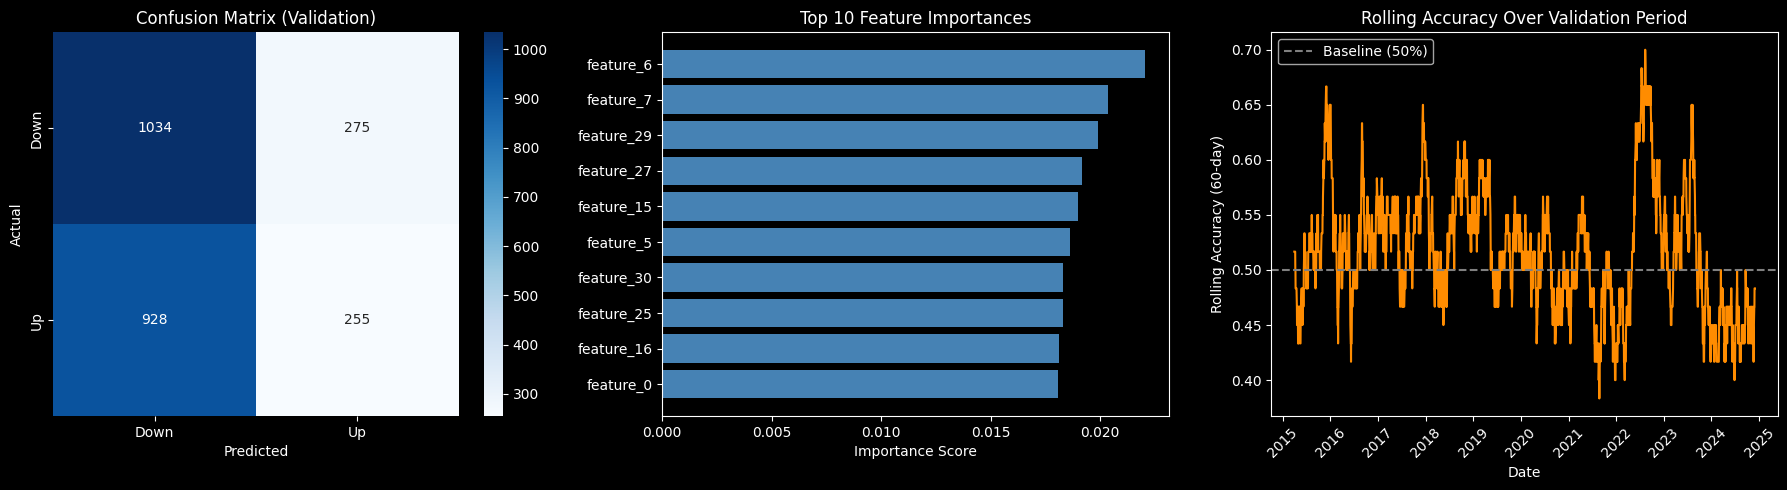

In [9]:
# ============================================================================
# 5. Visualizations
# ============================================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Confusion matrix heatmap (validation)
cm = confusion_matrix(y_val, val_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Down', 'Up'], yticklabels=['Down', 'Up'])
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_title('Confusion Matrix (Validation)')

# 2. Top 10 feature importances
imp = model.get_feature_importance().head(10)
axes[1].barh(imp['feature'][::-1], imp['importance'][::-1], color='steelblue')
axes[1].set_xlabel('Importance Score')
axes[1].set_title('Top 10 Feature Importances')

# 3. Rolling 60-day accuracy over the validation period
val_correct = (model.predict(X_val_sc) == y_val.values).astype(int)
rolling_acc = pd.Series(val_correct, index=val_df.index).rolling(60).mean()
axes[2].plot(rolling_acc.index, rolling_acc.values, color='darkorange')
axes[2].axhline(0.5, color='grey', linestyle='--', label='Baseline (50%)')
axes[2].set_xlabel('Date')
axes[2].set_ylabel('Rolling Accuracy (60-day)')
axes[2].set_title('Rolling Accuracy Over Validation Period')
axes[2].legend()
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

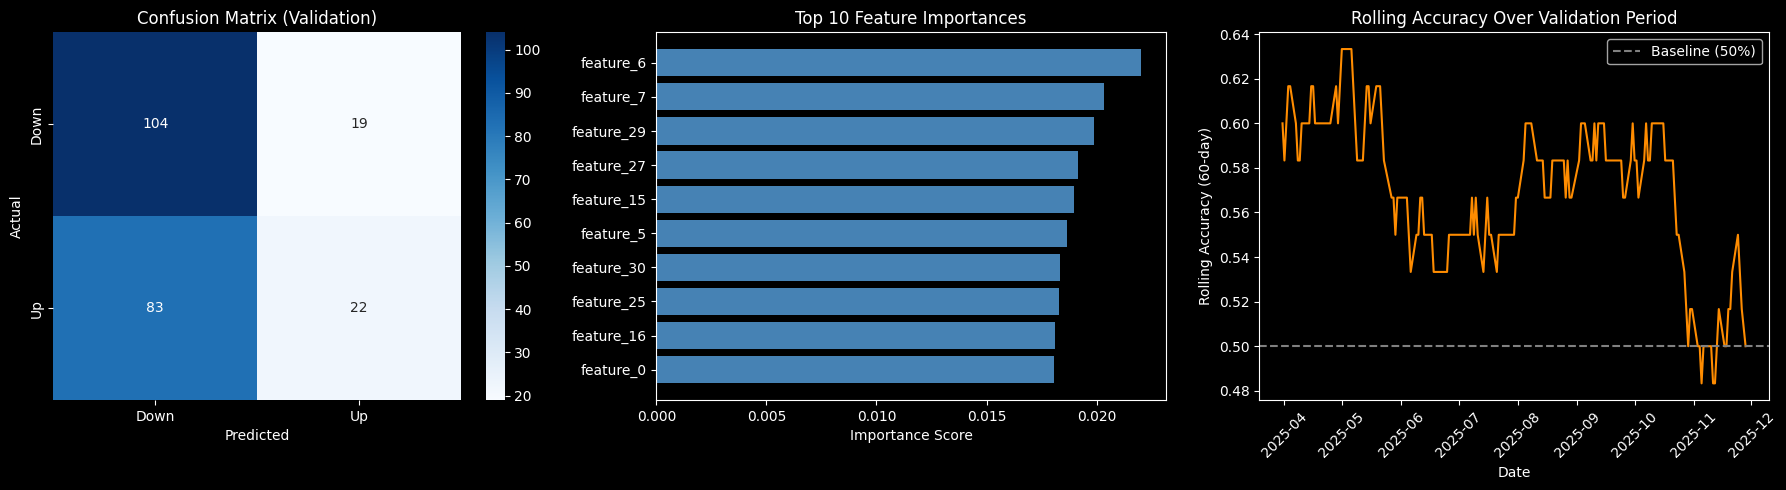

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Confusion matrix heatmap (validation)
cm = confusion_matrix(y_test, test_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Down', 'Up'], yticklabels=['Down', 'Up'])
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_title('Confusion Matrix (Validation)')

# 2. Top 10 feature importances
imp = model.get_feature_importance().head(10)
axes[1].barh(imp['feature'][::-1], imp['importance'][::-1], color='steelblue')
axes[1].set_xlabel('Importance Score')
axes[1].set_title('Top 10 Feature Importances')

# 3. Rolling 60-day accuracy over the validation period
test_correct = (model.predict(X_test_sc) == y_test.values).astype(int)
rolling_acc = pd.Series(test_correct, index=test_df.index).rolling(60).mean()
axes[2].plot(rolling_acc.index, rolling_acc.values, color='darkorange')
axes[2].axhline(0.5, color='grey', linestyle='--', label='Baseline (50%)')
axes[2].set_xlabel('Date')
axes[2].set_ylabel('Rolling Accuracy (60-day)')
axes[2].set_title('Rolling Accuracy Over Validation Period')
axes[2].legend()
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [11]:
# ============================================================================
# 6. Save and Load Model
# ============================================================================

model.save('transformer_wheat_model.pt')

# Reload and verify predictions are identical
loaded_model = TransformerForecastModel()
loaded_model.load('transformer_wheat_model.pt')

preds_orig   = model.predict(X_val_sc)
preds_loaded = loaded_model.predict(X_val_sc)
print(f'\nLoaded model matches: {np.array_equal(preds_orig, preds_loaded)}')

Model saved to transformer_wheat_model.pt
Model loaded from transformer_wheat_model.pt

Loaded model matches: True
